# Evolutionäres Constrain basiertes NAS

- Dataset: EuroSAT
- Model: timm ViT-Small pretrained (ImageNet)
- Search space: depth, heads, patch_size (prepared), SPT/LSA flags (prepared),
                finetune strategy + optimizer hyperparams
- NAS: population -> elite selection -> mutation -> generations
- Constraints: soft penalty (val_acc - lambda*params - mu*time)

### Imports

In [15]:
import time
import csv
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.5.1+cu121
12.1
True


In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)

Using device: cuda


In [4]:
def make_data_loaders(
    root="./data",
    image_size=224,
    batch_size=16,
    num_workers=2,
    seed=42,
):
    tfm = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),
    ])
    
    ds = datasets.EuroSAT(root=root, download=True, transform=tfm)
    
    n = len(ds)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    n_test = n - n_train - n_val
    
    g = torch.Generator().manual_seed(seed)
    train_ds, val_ds, test_ds = random_split(
        ds, [n_train, n_val, n_test], generator=g
    )
    
    use_pin = torch.cuda.is_available()
    
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=use_pin,
    persistent_workers=(num_workers > 0))
    
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=use_pin
    )
    
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=use_pin
    )
    
    return train_loader, val_loader, test_loader, len(ds.classes)

train_loader, val_loader, test_loader, num_classes = make_data_loaders()
print("Classes:", num_classes)

 19%|█▊        | 17.6M/94.3M [00:00<00:02, 33.3MB/s]


KeyboardInterrupt: 

## Cifar100

In [5]:
def make_cifar100_loaders(
    root="./data",
    image_size=224,
    batch_size=64,
    num_workers=4,
    seed=42,
):
    tfm_train = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406),
                             (0.229, 0.224, 0.225)),
    ])

    tfm_eval = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406),
                             (0.229, 0.224, 0.225)),
    ])

    full_train = datasets.CIFAR100(root=root, train=True, download=True, transform=tfm_train)
    test_ds = datasets.CIFAR100(root=root, train=False, download=True, transform=tfm_eval)

    # train/val split from training set
    n = len(full_train)
    n_train = int(0.9 * n)
    n_val = n - n_train

    g = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(full_train, [n_train, n_val], generator=g)

    # IMPORTANT: val_ds currently uses tfm_train because it's a Subset of full_train.
    # Quick fix: wrap val subset with eval transform
    val_ds.dataset.transform = tfm_eval

    use_pin = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=use_pin,
        persistent_workers=(num_workers > 0),
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=use_pin,
        persistent_workers=(num_workers > 0),
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=use_pin,
        persistent_workers=(num_workers > 0),
    )

    return train_loader, val_loader, test_loader, 100

train_loader, val_loader, test_loader, num_classes = make_cifar100_loaders()
print(num_classes)

100%|██████████| 169M/169M [00:08<00:00, 19.2MB/s] 


Extracting ./data\cifar-100-python.tar.gz to ./data
Files already downloaded and verified
100


# Shifted Patch Tokenization

In [6]:
class SPTPatchEmbed(nn.Module):
    """
    Shifted Patch Tokenization (SPT) as Patch Embedding replacement for ViT.
    Produces patch tokens with increased locality inductive bias by concatenating
    shifted versions of the input image along channel dimension.
    """
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_chans=3,
        embed_dim=384,
        vanilla=False,
        use_ln=True,
        eps=1e-6
    ):
        super().__init__()
        self.img_size = img_size if isinstance(img_size, int) else img_size[0]
        self.patch_size = patch_size if isinstance(patch_size, int) else patch_size[0]
        self.half_patch = self.patch_size // 2
        self.vanilla = vanilla
        self.use_ln = use_ln and (not vanilla)
        
        effective_in_chans = in_chans if vanilla else in_chans * 5
        
        self.proj = nn.Conv2d(
            effective_in_chans,
            embed_dim,
            kernel_size=self.patch_size,
            stride=self.patch_size
        )
        
        self.norm = nn.LayerNorm(embed_dim, eps=eps) if self.use_ln else nn.Identity()
        
    def _crop_shift_pad(self, x, mode: str):
        """
        Create diagonally shifted image by cropping and padding.
        x: (B, C, H, W)
        """
        hp = self.half_patch
        B, C, H, W = x.shape

        if mode == "left-up":
            top_crop, left_crop = hp, hp
            top_pad, left_pad = 0, 0
        elif mode == "left-down":
            top_crop, left_crop = 0, hp
            top_pad, left_pad = hp, 0
        elif mode == "right-up":
            top_crop, left_crop = hp, 0
            top_pad, left_pad = 0, hp
        elif mode == "right-down":
            top_crop, left_crop = 0, 0
            top_pad, left_pad = hp, hp
        else:
            raise ValueError(mode)

        x_crop = x[:, :, 
                top_crop:top_crop + (H - hp),
                left_crop:left_crop + (W - hp)]

        pad_bottom = H - x_crop.shape[2] - top_pad
        pad_right = W - x_crop.shape[3] - left_pad

        x_pad = F.pad(
            x_crop,
            (left_pad, pad_right, top_pad, pad_bottom)
        )

        return x_pad
    
    def forward(self, x):
        if not self.vanilla:
            x = torch.cat(
                [
                x, 
                self._crop_shift_pad(x, "left-up"),
                self._crop_shift_pad(x, "left-down"),
                self._crop_shift_pad(x, "right-up"),
                self._crop_shift_pad(x, "right-down"),
                ],
                dim = 1
            )
        
        x = self.proj(x)
        
        x = x.flatten(2).transpose(1, 2)
        
        x = self.norm(x)
        
        return x
        
    

In [7]:
def enable_spt(model, img_size=224, patch_size=16, vanilla=False):
    """
    Replace model.patch_embed with SPTPatchEmbed while keeping everything else identical.
    Assumes ViT-Small (embed_dim=384).
    """
    embed_dim = getattr(model, "embed_dim", 384)
    in_chans = 3
    
    model.patch_embed = SPTPatchEmbed(
        img_size=img_size,
        patch_size=patch_size,
        in_chans=in_chans,
        embed_dim=embed_dim,
        vanilla=vanilla,
        use_ln=True
    )
    
    return model

# Local Self-Attention

In [8]:
class LSA_Attention(nn.Module):
    """
    Drop-in replacement for timm ViT Attention with:
      - diagonal mask (no self-token attention)
      - learnable per-head scale (temperature)
    Based on common SPT+LSA implementations.  [oai_citation:1‡GitHub](https://raw.githubusercontent.com/aanna0701/SPT_LSA_ViT/main/models/vit.py)
    """
    def __init__(self, attn_module: nn.Module):
        super().__init__()
        
        # Grab needed parts from timm's Attention
        self.num_heads = attn_module.num_heads
        self.head_dim = attn_module.head_dim
        self.attn_drop = attn_module.attn_drop
        self.proj = attn_module.proj
        self.proj_drop = attn_module.proj_drop
        
        # timm attention uses a single scale
        # LSA makes it learnable per head
        init_scale = getattr(attn_module, "scale", self.head_dim ** -0.5)
        self.scale = nn.Parameter(torch.ones(self.num_heads) * float(init_scale))
        
        # qkv projection
        self.qkv = attn_module.qkv
        
        # small cache for diagonal masks by token-length (optional speed)
        self._mask_cache = {}

    def _diag_mask(self, n: int, device):
        key = (n, device)
        if key in self._mask_cache:
            return self._mask_cache[key]

        m = torch.eye(n, device=device, dtype=torch.bool)
        self._mask_cache[key] = m
        return m

    def forward(self, x, attn_mask=None, **kwargs):
        # attn_mask is passed by some timm blocks; we can ignore it for LSA
        # or optionally apply it (see section 2).
        B, N, C = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1))
        attn = attn * self.scale.view(1, self.num_heads, 1, 1)

        # LSA: mask diagonal (no self-attention)
        diag = self._diag_mask(N, x.device)
        attn = attn.masked_fill(diag.view(1, 1, N, N), float("-inf"))

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, C)

        out = self.proj(out)
        out = self.proj_drop(out)
        return out
        

In [9]:
def enable_lsa(model):
    for blk in model.blocks:
        blk.attn = LSA_Attention(blk.attn)
    return model

# ViT-Small Implementation

Builds a ViT-Small using timm with variable depth and num_heads (if supported by your timm version).

Notes:
    - patch_size is prepared in cfg but not applied yet due to pretrained compatibility complexity.
    - use_spt/use_lsa are flags prepared for later module integration.

In [10]:
def build_vit_from_cfg(num_classes, cfg):
    model = timm.create_model(
        "vit_small_patch16_224",
        pretrained=True,
        num_classes=num_classes,
        depth=cfg["depth"],
        num_heads=cfg["num_heads"],
    )

    if cfg["use_spt"] == 1:
        model = enable_spt(model, img_size=224, patch_size=16, vanilla=False)
        
    if cfg["use_lsa"] == 1: model = enable_lsa(model)
    
    # TODO: Mixed Resolution Tokenization

    mode = cfg.get("finetune_mode", "last2")

    # Freeze all
    for p in model.parameters():
        p.requires_grad = False

    # Train head always
    for p in model.head.parameters():
        p.requires_grad = True

    # Finetune modes
    if mode == "full":
        for p in model.parameters():
            p.requires_grad = True
    elif mode == "last2":
        for blk in model.blocks[-2:]:
            for p in blk.parameters():
                p.requires_grad = True
        for p in model.norm.parameters():
            p.requires_grad = True
    elif mode == "head":
        pass
    else:
        raise ValueError(mode)

    return model.to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [11]:
def accuracy_top1(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

def train_one_epoch(model, loader, optimizer):
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_top1(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_top1(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n

def quick_finetune(model, train_loader, val_loader, epochs=2, lr=3e-4, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    start = time.time()
    best_val_acc = 0.0

    for _ in range(epochs):
        train_one_epoch(model, train_loader, optimizer)
        _, val_acc = eval_one_epoch(model, val_loader)
        best_val_acc = max(best_val_acc, val_acc)

    return best_val_acc, time.time() - start

# For Mixed Precision (PyTorch AMP)

In [21]:
def accuracy_top1(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

def train_one_epoch_amp(model, loader, optimizer, scaler):
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device == "cuda")):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_top1(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n

@torch.no_grad()
def eval_one_epoch_amp(model, loader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda",enabled=(device == "cuda")):
            logits = model(x)
            loss = loss_fn(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_top1(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n

def quick_finetune(model, train_loader, val_loader, epochs=20, lr=3e-4, weight_decay=1e-4, patience=None):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    scaler = torch.amp.GradScaler(enabled=(device == "cuda"))

    start = time.time()
    best_val_acc = 0.0
    bad = 0

    for _ in range(epochs):
        train_one_epoch_amp(model, train_loader, optimizer, scaler)
        _, val_acc = eval_one_epoch_amp(model, val_loader)

        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            bad = 0
        else:
            bad += 1
            if patience is not None and bad >= patience:
                break

    return best_val_acc, time.time() - start

## Suchraum (SEARCH_SPACE)

Definiert den diskreten Architektur- und Trainingsraum für das evolutionäre NAS.

**Architekturparameter:**
- `patch_size` – Patch-Zerlegung der Eingabebilder  
- `depth` – Anzahl der Transformer-Blöcke  
- `num_heads` – Anzahl Attention-Heads (muss 384 teilen)  
- `use_spt` – Aktivierung von Shifted Patch Tokenization  
- `use_lsa` – Aktivierung von Local Self-Attention  
- `finetune_mode` – Umfang des Fine-Tunings (`last2`, `full`)

**Optimierungsparameter:**
- `lr` – Lernrate  
- `weight_decay` – Regularisierung  
- `e` – Proxy-Trainingsepochen  

→ Der Suchraum kombiniert strukturelle Architekturentscheidungen mit Trainingshyperparametern.

---

## sample_config

- Erzeugt eine zufällige Konfiguration aus dem definierten Suchraum  
- Stellt sicher, dass `num_heads` die Embedding-Dimension (384) teilt  
- Dient zur Initialisierung der Startpopulation  

→ Implementiert die zufällige Startverteilung im evolutionären NAS.

---

## mutate_config

- Erzeugt ein Kind-Modell durch zufällige Mutation einzelner Parameter  
- Jeder Parameter wird mit Wahrscheinlichkeit `p_mut` verändert  
- Validiert erneut architektonische Konsistenz (`num_heads`-Constraint)

→ Realisiert den explorativen Schritt der Evolution durch kontrollierte Variation.

In [23]:
SEARCH_SPACE = {
    "patch_size": [16],            # later: [16, 8] with proper pretrained adaptation
    "depth": [6, 8, 10, 12],
    "num_heads": [4, 6, 8],        # must divide embed_dim=384
    "use_spt": [0, 1],             
    "use_lsa": [0, 1],             
    "finetune_mode": ["last2", "full"],
    "lr": [1e-4, 3e-4, 1e-3],
    "weight_decay": [1e-4, 5e-4],
    "proxy_epochs": [5],
}

def sample_config(space=SEARCH_SPACE):
    cfg = {k: random.choice(v) for k, v in space.items()}

    # ensure heads divides embed_dim
    if 384 % cfg["num_heads"] != 0:
        valid = [h for h in space["num_heads"] if 384 % h == 0]
        cfg["num_heads"] = random.choice(valid)

    return cfg

def mutate_config(cfg, space=SEARCH_SPACE, p_mut=0.35):
    child = cfg.copy()
    for key, choices in space.items():
        if random.random() < p_mut:
            options = [c for c in choices if c != child[key]]
            child[key] = random.choice(options) if options else child[key]

    # ensure validity again
    if 384 % child["num_heads"] != 0:
        valid = [h for h in space["num_heads"] if 384 % h == 0]
        child["num_heads"] = random.choice(valid)

    return child

## Fitness-Funktion

- Bewertet jede Architektur mittels kombinierter Zielfunktion  
- Ziel: hohe Validation Accuracy bei geringer Modellgröße und Trainingszeit  
- Formel:  
  `fitness = val_acc − λ_params · params − λ_time · time`

→ Implementiert ein **constraint-basiertes NAS**, das Genauigkeit und Effizienz gemeinsam optimiert.

---

## normalize_cfg

- Ergänzt fehlende Hyperparameter durch Default-Werte  
- Setzt Trainingsparameter (Proxy-Epochen, LR, Weight Decay)  
- Definiert Architekturparameter (Depth, Heads, Patch Size, SPT, LSA)  
- Prüft architektonische Gültigkeit (z. B. Teilbarkeit der Embedding-Dimension durch `num_heads`)

→ Stellt sicher, dass nur valide und konsistente ViT-Konfigurationen trainiert werden.

---

## evaluate_cfg

- Baut das Vision-Transformer-Modell aus der Konfiguration  
- Optional: übernimmt kompatible Gewichte vom Elternmodell (Weight Inheritance)  
- Führt Proxy-Fine-Tuning durch  
- Berechnet Fitness-Wert  
- Gibt Architektur + Performance-Metriken zurück  

→ Zentrale Evaluationskomponente im evolutionären NAS-Prozess.

In [ ]:
def fitness(val_acc, params, time_sec, lam_params=1e-8, lam_time=0.02):
    return val_acc - lam_params * params - lam_time * (time_sec / 60.0)

def normalize_cfg(cfg):
    cfg = dict(cfg)  

    cfg.setdefault("proxy_epochs", 5)
    cfg.setdefault("lr", 3e-4)
    cfg.setdefault("weight_decay", 1e-4)
    cfg.setdefault("finetune_mode", "head")

    cfg.setdefault("patch_size", 16)
    cfg.setdefault("depth", 12)
    cfg.setdefault("num_heads", 6)
    cfg.setdefault("use_spt", 0)
    cfg.setdefault("use_lsa", 0)

    # validity
    if 384 % cfg["num_heads"] != 0:
        cfg["num_heads"] = 6

    return cfg

def evaluate_cfg(cfg, parent_state_dict=None):
    cfg = normalize_cfg(cfg)

    model = build_vit_from_cfg(num_classes, cfg)
    
    if parent_state_dict is not None:
        model.load_state_dict(parent_state_dict, strict=False)
    
    params = count_params(model)

    val_acc, secs = quick_finetune(
        model, train_loader, val_loader,
        epochs=cfg.get("proxy_epochs", 2),
        lr=cfg.get("lr", 3e-4),
        weight_decay=cfg.get("weight_decay", 1e-4)
    )

    fit = fitness(val_acc, params, secs)

    return {
        **cfg,
        "val_acc": val_acc,
        "time_sec": secs,
        "params": params,
        "fitness": fit
    }

# Evolutionäres NAS

Hierbei erbt jede Generation Gewichte von Elite Modellen

Neue Layer werden automatisch neu initialisiert

Fitness bleibt constraint-basiert

Proxy-Training bleibt erhalten

### Funktionsweise des evolutionären NAS

In diesem Projekt wird ein evolutionäres, constraint-basiertes Neural Architecture Search (NAS) eingesetzt, um geeignete Vision-Transformer-Architekturen für die EuroSAT-Klassifikation zu finden.

Ablauf
1.	Initialisierung
Eine Population zufälliger Architekturkonfigurationen wird aus dem definierten Suchraum (SEARCH_SPACE) erzeugt. \n


2.	Evaluation
Jede Architektur wird für wenige Epochen trainiert (Proxy-Training) und anhand einer Fitness-Funktion bewertet.
Die Fitness berücksichtigt:
- Validation Accuracy
- Parameteranzahl
- Trainingszeit

3.	Selektion (Elite Selection)
Die besten k Architekturen werden als „Eliten“ ausgewählt.
4.	Mutation
Neue Kandidaten entstehen durch Mutation architektureller Parameter wie:
- depth (Anzahl Transformer-Blöcke)
- num_heads
- use_spt
- use_lsa
- finetune_mode

5.	Iteration
Der Prozess wiederholt sich über mehrere Generationen.

⸻

### Weight Inheritance

Um die Rechenkosten zu reduzieren, wird Weight Inheritance eingesetzt:
- Kinderarchitekturen übernehmen – sofern möglich – die Gewichte des Elternmodells.
- Nicht kompatible Layer werden neu initialisiert (strict=False).

Dadurch wird Training beschleunigt, da Modelle nicht immer vollständig neu trainiert werden müssen.

⸻

### Wichtige Einschränkung bei Weight Inheritance

Weight Inheritance ist nur sinnvoll, wenn die zugrunde liegende Architektur strukturell kompatibel bleibt.

Problematisch ist es, Gewichte zu übernehmen, wenn sich zentrale Architekturkomponenten ändern, z. B.:
- Aktivierung/Deaktivierung von Shifted Patch Tokenization (SPT)
- Aktivierung/Deaktivierung von Local Self-Attention (LSA)
- Änderung der Embedding-Dimension oder Attention-Struktur

Solche Änderungen verändern die Feature-Verteilung oder Tensorformen erheblich.
Wird dennoch vererbt, kann dies:
- zu instabilem Training führen
- bestimmte Architekturvarianten systematisch benachteiligen
- die NAS-Suche verzerren

Daher sollte Weight Inheritance nur bei kompatiblen Mutationen (z. B. identischer Depth und Head-Anzahl) angewendet werden

In [28]:
def evolutionary_nas(
    pop_size=10,
    generations=10,
    elite_k=3,
    p_mut=0.35,
    seed=42,
    log_csv_path="enas_cifar100.csv"
):
    random.seed(seed)

    population = [sample_config() for _ in range(pop_size)]
    all_results = []

    fieldnames = list(SEARCH_SPACE.keys()) + ["val_acc", "time_sec", "params", "fitness", "generation", "rank"]

    with open(log_csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for gen in range(generations):
            print(f"\n=== Generation {gen} ===")
            gen_results = []

            for i, cfg in enumerate(population):
                parent_state = cfg.get("state_dict", None)
                
                res = evaluate_cfg(cfg)
                gen_results.append(res)
                print(
                    f"  [{i:02d}] "
                    f"val_acc={res['val_acc']:.4f} "
                    f"fitness={res['fitness']:.4f} "
                    f"params={res['params']/1e6:.1f}M "
                    f"time={res['time_sec']:.1f}s "
                    f"cfg(depth={res['depth']}, heads={res['num_heads']}, spt={res['use_spt']}, lsa={res['use_lsa']}, ft={res['finetune_mode']})"
                )

            gen_results = sorted(gen_results, key=lambda x: x["fitness"], reverse=True)

            for rank, res in enumerate(gen_results):
                row = {k: res[k] for k in SEARCH_SPACE.keys()}
                row.update({
                    "val_acc": res["val_acc"],
                    "time_sec": res["time_sec"],
                    "params": res["params"],
                    "fitness": res["fitness"],
                    "generation": gen,
                    "rank": rank
                })
                writer.writerow(row)

            all_results.extend([{**r, "generation": gen} for r in gen_results])

            elites = gen_results[:elite_k]

            # next population: mutate elites
            new_population = []
            while len(new_population) < pop_size:
                parent = random.choice(elites)
                parent_cfg = {k: parent[k] for k in SEARCH_SPACE.keys()}
                child_cfg = mutate_config(parent_cfg, p_mut=p_mut)
                
                if (
                    parent["depth"] == child_cfg["depth"] and
                    parent["num_heads"] == child_cfg["num_heads"] and
                    parent["use_spt"] == child_cfg["use_spt"] and
                    parent["use_lsa"] == child_cfg["use_lsa"]
                    and "state_dict" in parent
                ):
                    child_cfg["state_dict"] = parent["state_dict"]
                
                new_population.append(child_cfg)

            population = new_population

    return all_results

In [29]:
results = evolutionary_nas(
    pop_size=10,
    generations=10,
    elite_k=3,
    p_mut=0.35,
    log_csv_path="enas_cifar100.csv"
)

print("\nDone. Results written to CSV")


=== Generation 0 ===


Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight, blocks.6.attn.proj.bias, blocks.6.attn.proj.weight, blocks.6.attn.qkv.bias, blocks.6.attn.qkv.weight, blocks.6.mlp.fc1.bias, blocks.6.mlp.fc1.weight, blocks.6.mlp.fc2.bias, blocks.6.mlp.fc2.weight, blocks.6.norm1.bias, blocks.6.norm1.weight, blocks.6.norm2.bias, blocks.6.norm2.weight, blocks.7.attn.proj.bias, blocks.7.attn.proj.weight, blocks.7.attn.qkv.bias, blocks.7.attn.qkv.weight,

  [00] val_acc=0.3846 fitness=0.1965 params=12.2M time=197.2s cfg(depth=6, heads=8, spt=1, lsa=0, ft=last2)


Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight, blocks.6.attn.proj.bias, blocks.6.attn.proj.weight, blocks.6.attn.qkv.bias, blocks.6.attn.qkv.weight, blocks.6.mlp.fc1.bias, blocks.6.mlp.fc1.weight, blocks.6.mlp.fc2.bias, blocks.6.mlp.fc2.weight, blocks.6.norm1.bias, blocks.6.norm1.weight, blocks.6.norm2.bias, blocks.6.norm2.weight, blocks.7.attn.proj.bias, blocks.7.attn.proj.weight, blocks.7.attn.qkv.bias, blocks.7.attn.qkv.weight,

  [01] val_acc=0.6022 fitness=0.4310 params=11.1M time=182.0s cfg(depth=6, heads=4, spt=0, lsa=0, ft=last2)


...

  [07] val_acc=0.6688 fitness=0.4145 params=11.1M time=431.2s cfg(depth=6, heads=6, spt=0, lsa=1, ft=full)


Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight, blocks.8.attn.proj.bias, blocks.8.attn.proj.weight, blocks.8.attn.qkv.bias, blocks.8.attn.qkv.weight, blocks.8.mlp.fc1.bias, blocks.8.mlp.fc1.weight, blocks.8.mlp.fc2.bias, blocks.8.mlp.fc2.weight, blocks.8.norm1.bias, blocks.8.norm1.weight, blocks.8.norm2.bias, blocks.8.norm2.weight, blocks.9.attn.proj.bias, blocks.9.attn.proj.weight, blocks.9.attn.qkv.bias, blocks.9.attn.qkv.weight,

  [08] val_acc=0.3498 fitness=0.0877 params=15.8M time=312.7s cfg(depth=8, heads=6, spt=1, lsa=1, ft=last2)


Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight, blocks.6.attn.proj.bias, blocks.6.attn.proj.weight, blocks.6.attn.qkv.bias, blocks.6.attn.qkv.weight, blocks.6.mlp.fc1.bias, blocks.6.mlp.fc1.weight, blocks.6.mlp.fc2.bias, blocks.6.mlp.fc2.weight, blocks.6.norm1.bias, blocks.6.norm1.weight, blocks.6.norm2.bias, blocks.6.norm2.weight, blocks.7.attn.proj.bias, blocks.7.attn.proj.weight, blocks.7.attn.qkv.bias, blocks.7.attn.qkv.weight,

  [09] val_acc=0.6170 fitness=0.4311 params=11.1M time=226.0s cfg(depth=6, heads=4, spt=0, lsa=1, ft=last2)

Done. Results written to CSV


In [9]:
enas_df = pd.read_csv("enas_cifar100.csv")
enas_df.head()

,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,proxy_epochs,val_acc,time_sec,params,fitness,generation,rank
0,16,6,4,0,0,last2,0.0010,0.0001,5,0.6022,182.015210,11057380,0.430954,0,0
1,16,6,4,0,1,last2,0.0001,0.0001,5,0.6182,235.795175,11057404,0.429028,0,1
2,16,8,8,0,0,full,0.0003,0.0005,5,0.6952,405.057583,14606308,0.414118,0,2
3,16,6,4,0,1,full,0.0003,0.0001,5,0.6410,404.334749,11057404,0.395648,0,3
4,16,6,8,1,0,last2,0.0001,0.0001,5,0.3846,197.214382,12237796,0.196484,0,4


In [32]:
enas_df.sort_values("fitness", ascending=False).head(20)

,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,proxy_epochs,val_acc,time_sec,params,fitness,generation,rank
50,16,10,6,0,0,last2,0.0001,0.0005,5,0.8132,225.859128,18155236,0.556361,5,0
60,16,10,6,0,0,last2,0.0001,0.0001,5,0.8108,226.331010,18155236,0.553804,6,0
90,16,10,6,0,0,last2,0.0003,0.0005,5,0.8052,218.764402,18155236,0.550726,9,0
80,16,8,6,0,0,last2,0.0003,0.0005,5,0.7588,193.229803,14606308,0.548327,8,0
40,16,8,6,0,0,last2,0.0003,0.0005,5,0.7570,197.358562,14606308,0.545151,4,0
81,16,6,6,0,0,last2,0.0001,0.0001,5,0.7032,168.039326,11057380,0.536613,8,1
91,16,6,6,0,0,last2,0.0003,0.0005,5,0.6988,170.794423,11057380,0.531295,9,1
51,16,6,6,0,0,last2,0.0003,0.0001,5,0.6988,170.807199,11057380,0.531290,5,1
61,16,6,6,0,0,last2,0.0003,0.0001,5,0.6990,173.448973,11057380,0.530610,6,1
82,16,6,6,0,0,last2,0.0003,0.0001,5,0.6962,167.824127,11057380,0.529685,8,2


In [33]:
enas_df.sort_values("val_acc", ascending=False).head(10)

,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,proxy_epochs,val_acc,time_sec,params,fitness,generation,rank
44,16,12,6,0,0,full,0.0001,0.0005,5,0.8640,565.185635,21704164,0.458563,4,4
75,16,10,6,0,1,full,0.0001,0.0001,5,0.8312,692.030400,18155296,0.418970,7,5
63,16,12,6,0,0,last2,0.0003,0.0001,5,0.8144,249.676049,21704164,0.514133,6,3
50,16,10,6,0,0,last2,0.0001,0.0005,5,0.8132,225.859128,18155236,0.556361,5,0
43,16,12,6,0,1,last2,0.0003,0.0001,5,0.8114,388.460479,21704236,0.464871,4,3
60,16,10,6,0,0,last2,0.0001,0.0001,5,0.8108,226.331010,18155236,0.553804,6,0
90,16,10,6,0,0,last2,0.0003,0.0005,5,0.8052,218.764402,18155236,0.550726,9,0
72,16,10,6,0,1,last2,0.0003,0.0005,5,0.7960,335.902688,18155296,0.502479,7,2
74,16,10,8,0,0,full,0.0001,0.0001,5,0.7938,481.401350,18155236,0.451781,7,4
37,16,12,6,0,0,full,0.0003,0.0001,5,0.7904,564.507250,21704164,0.385189,3,7


In [20]:
enas_df.groupby("depth")["val_acc"].mean()

depth
6     0.596922
8     0.604678
10    0.594612
12    0.585040
Name: val_acc, dtype: float64

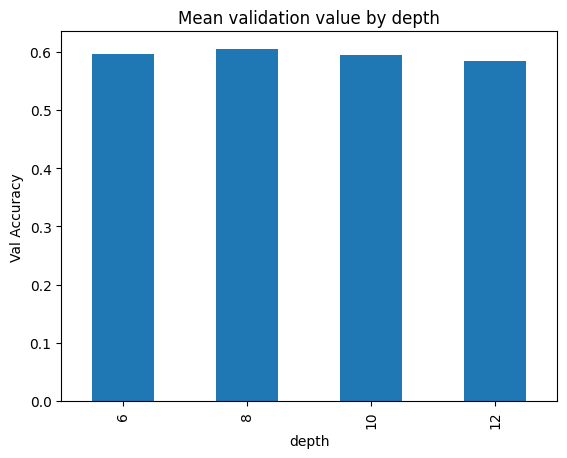

In [36]:
enas_df.groupby("depth")["val_acc"].mean().plot(kind="bar")
plt.title("Mean validation value by depth")
plt.ylabel("Val Accuracy")
plt.show()

In [22]:
enas_df.groupby("use_spt")["fitness"].mean()


use_spt
0    0.448576
1    0.109377
Name: fitness, dtype: float64

In [24]:
enas_df.groupby("use_lsa")["fitness"].mean()

use_lsa
0    0.357557
1    0.322225
Name: fitness, dtype: float64

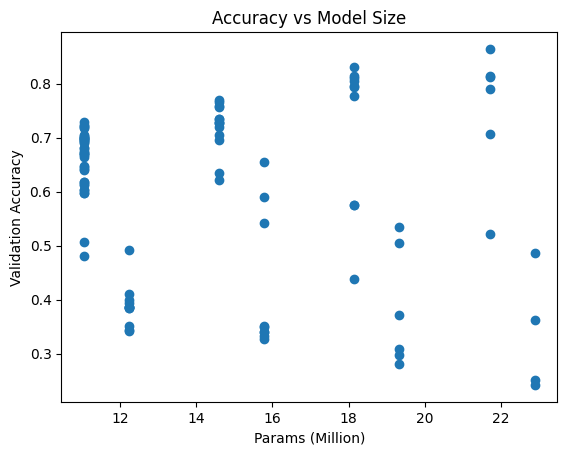

In [40]:
plt.scatter(enas_df["params"] / 1e6, enas_df["val_acc"])
plt.xlabel("Params (Million)")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy vs Model Size")
plt.show()

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(enas_df["params"] / 1e6, enas_df["val_acc"], alpha=0.7)

plt.xlabel("Parameters (Million)")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy vs Model Size")
plt.grid(True)
plt.show()

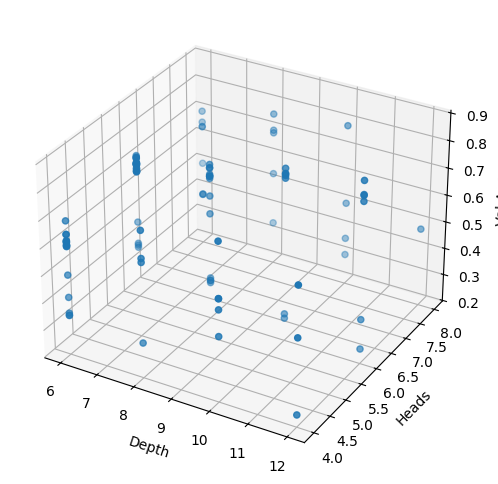

In [39]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(enas_df["depth"], enas_df["num_heads"], enas_df["val_acc"])

ax.set_xlabel("Depth")
ax.set_ylabel("Heads")
ax.set_zlabel("Val Acc")

plt.show()

In [42]:
best_per_gen = enas_df[enas_df["rank"] == 0]
best_per_gen

,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,proxy_epochs,val_acc,time_sec,params,fitness,generation,rank
0,16,6,4,0,0,last2,0.0010,0.0001,5,0.6022,182.015210,11057380,0.430954,0,0
10,16,6,6,0,0,last2,0.0010,0.0005,5,0.6808,171.588939,11057380,0.513030,1,0
20,16,8,6,0,0,last2,0.0010,0.0005,5,0.7272,198.257193,14606308,0.515051,2,0
30,16,6,6,0,0,last2,0.0003,0.0001,5,0.6960,173.060886,11057380,0.527739,3,0
40,16,8,6,0,0,last2,0.0003,0.0005,5,0.7570,197.358562,14606308,0.545151,4,0
50,16,10,6,0,0,last2,0.0001,0.0005,5,0.8132,225.859128,18155236,0.556361,5,0
60,16,10,6,0,0,last2,0.0001,0.0001,5,0.8108,226.331010,18155236,0.553804,6,0
70,16,6,6,0,0,last2,0.0003,0.0001,5,0.6924,167.684403,11057380,0.525931,7,0
80,16,8,6,0,0,last2,0.0003,0.0005,5,0.7588,193.229803,14606308,0.548327,8,0
90,16,10,6,0,0,last2,0.0003,0.0005,5,0.8052,218.764402,18155236,0.550726,9,0


In [70]:
top5 = (
    enas_df.sort_values("fitness", ascending=False).drop_duplicates(subset=["depth", "num_heads", "use_spt", "use_lsa", "finetune_mode"]).head(5)
)

top5

,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,proxy_epochs,val_acc,time_sec,params,fitness,generation,rank
50,16,10,6,0,0,last2,0.0001,0.0005,5,0.8132,225.859128,18155236,0.556361,5,0
80,16,8,6,0,0,last2,0.0003,0.0005,5,0.7588,193.229803,14606308,0.548327,8,0
81,16,6,6,0,0,last2,0.0001,0.0001,5,0.7032,168.039326,11057380,0.536613,8,1
71,16,8,6,0,1,last2,0.0001,0.0005,5,0.7700,294.821623,14606356,0.525663,7,1
62,16,6,6,0,0,full,0.0001,0.0001,5,0.7280,298.080886,11057380,0.518066,6,2


In [69]:
top10 = (
    enas_df.sort_values("val_acc", ascending=False).drop_duplicates(subset=["depth", "num_heads", "use_spt", "use_lsa", "finetune_mode"]).head(10)
)

top10

,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,proxy_epochs,val_acc,time_sec,params,fitness,generation,rank
44,16,12,6,0,0,full,0.0001,0.0005,5,0.8640,565.185635,21704164,0.458563,4,4
75,16,10,6,0,1,full,0.0001,0.0001,5,0.8312,692.030400,18155296,0.418970,7,5
63,16,12,6,0,0,last2,0.0003,0.0001,5,0.8144,249.676049,21704164,0.514133,6,3
50,16,10,6,0,0,last2,0.0001,0.0005,5,0.8132,225.859128,18155236,0.556361,5,0
43,16,12,6,0,1,last2,0.0003,0.0001,5,0.8114,388.460479,21704236,0.464871,4,3
72,16,10,6,0,1,last2,0.0003,0.0005,5,0.7960,335.902688,18155296,0.502479,7,2
74,16,10,8,0,0,full,0.0001,0.0001,5,0.7938,481.401350,18155236,0.451781,7,4
57,16,10,4,0,1,full,0.0001,0.0001,5,0.7772,638.310735,18155276,0.382877,5,7
71,16,8,6,0,1,last2,0.0001,0.0005,5,0.7700,294.821623,14606356,0.525663,7,1
84,16,8,8,0,0,full,0.0001,0.0005,5,0.7652,393.633783,14606308,0.487926,8,4


In [73]:
worst3 = (
    enas_df.sort_values("fitness", ascending=True).drop_duplicates(subset=["depth", "num_heads", "use_spt", "use_lsa", "finetune_mode"]).head(3)
)

worst3

,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,proxy_epochs,val_acc,time_sec,params,fitness,generation,rank
89,16,12,6,1,1,full,0.001,0.0001,5,0.3620,849.200845,22884652,-0.149913,8,9
49,16,10,8,1,1,full,0.001,0.0001,5,0.3710,812.141948,19335732,-0.093071,4,9
19,16,12,4,1,0,last2,0.001,0.0001,5,0.2422,285.128413,22884580,-0.081689,1,9


In [57]:
top_configs = top5[[
    "patch_size",
    "depth",
    "num_heads",
    "use_spt",
    "use_lsa",
    "finetune_mode",
    "lr",
    "weight_decay"
]].to_dict(orient="records")

top_configs

[{'patch_size': 16,
  'depth': 10,
  'num_heads': 6,
  'use_spt': 0,
  'use_lsa': 0,
  'finetune_mode': 'last2',
  'lr': 0.0001,
  'weight_decay': 0.0005},
 {'patch_size': 16,
  'depth': 8,
  'num_heads': 6,
  'use_spt': 0,
  'use_lsa': 0,
  'finetune_mode': 'last2',
  'lr': 0.0003,
  'weight_decay': 0.0005},
 {'patch_size': 16,
  'depth': 6,
  'num_heads': 6,
  'use_spt': 0,
  'use_lsa': 0,
  'finetune_mode': 'last2',
  'lr': 0.0001,
  'weight_decay': 0.0001},
 {'patch_size': 16,
  'depth': 8,
  'num_heads': 6,
  'use_spt': 0,
  'use_lsa': 1,
  'finetune_mode': 'last2',
  'lr': 0.0001,
  'weight_decay': 0.0005},
 {'patch_size': 16,
  'depth': 6,
  'num_heads': 6,
  'use_spt': 0,
  'use_lsa': 0,
  'finetune_mode': 'full',
  'lr': 0.0001,
  'weight_decay': 0.0001}]

In [67]:
def full_train(
    model,
    train_loader,
    val_loader,
    test_loader,
    epochs=100,
    lr=5e-5,
    weight_decay=1e-3
):

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )

    scaler = torch.amp.GradScaler(enabled=(device == "cuda"))

    best_val = 0.0
    best_state = None

    history = []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch_amp(
            model, train_loader, optimizer, scaler
        )

        val_loss, val_acc = eval_one_epoch_amp(
            model, val_loader
        )

        history.append({
            "epoch": epoch,
            "train_acc": train_acc,
            "val_acc": val_acc
        })

        print(
            f"Epoch {epoch+1:03d}/{epochs} | "
            f"train_acc={train_acc:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        if val_acc > best_val:
            best_val = val_acc
            best_state = model.state_dict()

    # restore best model
    model.load_state_dict(best_state)

    _, test_acc = eval_one_epoch_amp(model, test_loader)

    return best_val, test_acc, history

In [68]:
final_results = []

for i, cfg in enumerate(top_configs):
    print(f"\n=== True Training Model {i} ===")

    model = build_vit_from_cfg(num_classes, cfg)

    best_val, test_acc, history = full_train(
        model,
        train_loader,
        val_loader,
        test_loader,
        epochs=20,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    final_results.append({
        **cfg,
        "best_val": best_val,
        "test_acc": test_acc
    })

pd.DataFrame(final_results)


=== True Training Model 0 ===


Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Epoch 001/20 | train_acc=0.6428 | val_acc=0.7758
Epoch 002/20 | train_acc=0.8454 | val_acc=0.8082
Epoch 003/20 | train_acc=0.9158 | val_acc=0.8056
Epoch 004/20 | train_acc=0.9624 | val_acc=0.8124
Epoch 005/20 | train_acc=0.9857 | val_acc=0.8180
Epoch 006/20 | train_acc=0.9946 | val_acc=0.8164
Epoch 007/20 | train_acc=0.9969 | val_acc=0.8138
Epoch 008/20 | train_acc=0.9974 | val_acc=0.8118
Epoch 009/20 | train_acc=0.9898 | val_acc=0.7980
Epoch 010/20 | train_acc=0.9941 | val_acc=0.8064
Epoch 011/20 | train_acc=0.9976 | val_acc=0.8114
Epoch 012/20 | train_acc=0.9986 | val_acc=0.8094
Epoch 013/20 | train_acc=0.9944 | val_acc=0.8008
Epoch 014/20 | train_acc=0.9927 | val_acc=0.8078
Epoch 015/20 | train_acc=0.9977 | val_acc=0.8066
Epoch 016/20 | train_acc=0.9952 | val_acc=0.8074
Epoch 017/20 | train_acc=0.9964 | val_acc=0.8010
Epoch 018/20 | train_acc=0.9961 | val_acc=0.7996
Epoch 019/20 | train_acc=0.9960 | val_acc=0.8020
Epoch 020/20 | train_acc=0.9980 | val_acc=0.8042

=== True Training M

Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight, blocks.8.attn.proj.bias, blocks.8.attn.proj.weight, blocks.8.attn.qkv.bias, blocks.8.attn.qkv.weight, blocks.8.mlp.fc1.bias, blocks.8.mlp.fc1.weight, blocks.8.mlp.fc2.bias, blocks.8.mlp.fc2.weight, blocks.8.norm1.bias, blocks.8.norm1.weight, blocks.8.norm2.bias, blocks.8.norm2.weight, blocks.9.attn.proj.bias, blocks.9.attn.proj.weight, blocks.9.attn.qkv.bias, blocks.9.attn.qkv.weight,

Epoch 001/20 | train_acc=0.6228 | val_acc=0.7332
Epoch 002/20 | train_acc=0.8217 | val_acc=0.7580
Epoch 003/20 | train_acc=0.9114 | val_acc=0.7530
Epoch 004/20 | train_acc=0.9586 | val_acc=0.7586
Epoch 005/20 | train_acc=0.9739 | val_acc=0.7490
Epoch 006/20 | train_acc=0.9691 | val_acc=0.7450
Epoch 007/20 | train_acc=0.9705 | val_acc=0.7338
Epoch 008/20 | train_acc=0.9763 | val_acc=0.7408
Epoch 009/20 | train_acc=0.9796 | val_acc=0.7466
Epoch 010/20 | train_acc=0.9784 | val_acc=0.7492
Epoch 011/20 | train_acc=0.9816 | val_acc=0.7536
Epoch 012/20 | train_acc=0.9802 | val_acc=0.7604
Epoch 013/20 | train_acc=0.9820 | val_acc=0.7596
Epoch 014/20 | train_acc=0.9836 | val_acc=0.7586
Epoch 015/20 | train_acc=0.9837 | val_acc=0.7590
Epoch 016/20 | train_acc=0.9829 | val_acc=0.7502
Epoch 017/20 | train_acc=0.9846 | val_acc=0.7496
Epoch 018/20 | train_acc=0.9858 | val_acc=0.7462
Epoch 019/20 | train_acc=0.9901 | val_acc=0.7486
Epoch 020/20 | train_acc=0.9841 | val_acc=0.7452

=== True Training M

...

Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight, blocks.8.attn.proj.bias, blocks.8.attn.proj.weight, blocks.8.attn.qkv.bias, blocks.8.attn.qkv.weight, blocks.8.mlp.fc1.bias, blocks.8.mlp.fc1.weight, blocks.8.mlp.fc2.bias, blocks.8.mlp.fc2.weight, blocks.8.norm1.bias, blocks.8.norm1.weight, blocks.8.norm2.bias, blocks.8.norm2.weight, blocks.9.attn.proj.bias, blocks.9.attn.proj.weight, blocks.9.attn.qkv.bias, blocks.9.attn.qkv.weight,

Epoch 001/20 | train_acc=0.5534 | val_acc=0.6980
Epoch 002/20 | train_acc=0.7815 | val_acc=0.7390
Epoch 003/20 | train_acc=0.8679 | val_acc=0.7554
Epoch 004/20 | train_acc=0.9334 | val_acc=0.7632
Epoch 005/20 | train_acc=0.9741 | val_acc=0.7688
Epoch 006/20 | train_acc=0.9926 | val_acc=0.7722
Epoch 007/20 | train_acc=0.9971 | val_acc=0.7772
Epoch 008/20 | train_acc=0.9975 | val_acc=0.7712
Epoch 009/20 | train_acc=0.9945 | val_acc=0.7524
Epoch 010/20 | train_acc=0.9944 | val_acc=0.7540
Epoch 011/20 | train_acc=0.9978 | val_acc=0.7670
Epoch 012/20 | train_acc=0.9986 | val_acc=0.7704
Epoch 013/20 | train_acc=0.9888 | val_acc=0.7600
Epoch 014/20 | train_acc=0.9966 | val_acc=0.7600
Epoch 015/20 | train_acc=0.9994 | val_acc=0.7726
Epoch 016/20 | train_acc=0.9981 | val_acc=0.7568
Epoch 017/20 | train_acc=0.9885 | val_acc=0.7606
Epoch 018/20 | train_acc=0.9967 | val_acc=0.7570
Epoch 019/20 | train_acc=0.9984 | val_acc=0.7686
Epoch 020/20 | train_acc=0.9985 | val_acc=0.7480

=== True Training M

Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight, blocks.6.attn.proj.bias, blocks.6.attn.proj.weight, blocks.6.attn.qkv.bias, blocks.6.attn.qkv.weight, blocks.6.mlp.fc1.bias, blocks.6.mlp.fc1.weight, blocks.6.mlp.fc2.bias, blocks.6.mlp.fc2.weight, blocks.6.norm1.bias, blocks.6.norm1.weight, blocks.6.norm2.bias, blocks.6.norm2.weight, blocks.7.attn.proj.bias, blocks.7.attn.proj.weight, blocks.7.attn.qkv.bias, blocks.7.attn.qkv.weight,

Epoch 001/20 | train_acc=0.4745 | val_acc=0.6206
Epoch 002/20 | train_acc=0.7319 | val_acc=0.6806
Epoch 003/20 | train_acc=0.8381 | val_acc=0.7002
Epoch 004/20 | train_acc=0.9159 | val_acc=0.7034
Epoch 005/20 | train_acc=0.9630 | val_acc=0.7168
Epoch 006/20 | train_acc=0.9775 | val_acc=0.7136
Epoch 007/20 | train_acc=0.9756 | val_acc=0.6870
Epoch 008/20 | train_acc=0.9712 | val_acc=0.7156
Epoch 009/20 | train_acc=0.9790 | val_acc=0.7216
Epoch 010/20 | train_acc=0.9827 | val_acc=0.7114
Epoch 011/20 | train_acc=0.9758 | val_acc=0.7034
Epoch 012/20 | train_acc=0.9805 | val_acc=0.7202
Epoch 013/20 | train_acc=0.9867 | val_acc=0.6922
Epoch 014/20 | train_acc=0.9772 | val_acc=0.7130
Epoch 015/20 | train_acc=0.9847 | val_acc=0.7234
Epoch 016/20 | train_acc=0.9861 | val_acc=0.7030
Epoch 017/20 | train_acc=0.9834 | val_acc=0.7128
Epoch 018/20 | train_acc=0.9838 | val_acc=0.7168
Epoch 019/20 | train_acc=0.9854 | val_acc=0.7102
Epoch 020/20 | train_acc=0.9867 | val_acc=0.6990


,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,best_val,test_acc
0,16,10,6,0,0,last2,0.0001,0.0005,0.8180,0.8092
1,16,8,6,0,0,last2,0.0003,0.0005,0.7604,0.7527
2,16,6,6,0,0,last2,0.0001,0.0001,0.7232,0.6950
3,16,8,6,0,1,last2,0.0001,0.0005,0.7772,0.7497
4,16,6,6,0,0,full,0.0001,0.0001,0.7234,0.7111


In [84]:
pd.DataFrame(final_results)

,patch_size,depth,num_heads,use_spt,use_lsa,finetune_mode,lr,weight_decay,best_val,test_acc
0,16,12,6,1,1,full,0.001,0.0001,0.412,0.3914


In [80]:
worst_configs = worst3[[
    "patch_size",
    "depth",
    "num_heads",
    "use_spt",
    "use_lsa",
    "finetune_mode",
    "lr",
    "weight_decay"
]].to_dict(orient="records")

worst_configs

worst_config = worst_configs[2]

In [83]:
final_results = []

for i, cfg in enumerate(worst_configs):
    print(f"\n=== True Training Model {i} ===")

    model = build_vit_from_cfg(num_classes, cfg)

    best_val, test_acc, history = full_train(
        model,
        train_loader,
        val_loader,
        test_loader,
        epochs=20,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    final_results.append({
        **cfg,
        "best_val": best_val,
        "test_acc": test_acc
    })

pd.DataFrame(final_results)


=== True Training Model 0 ===
Epoch 001/20 | train_acc=0.1031 | val_acc=0.1746
Epoch 002/20 | train_acc=0.1995 | val_acc=0.2140
Epoch 003/20 | train_acc=0.2616 | val_acc=0.3012
Epoch 004/20 | train_acc=0.3188 | val_acc=0.3188
Epoch 005/20 | train_acc=0.3639 | val_acc=0.3496
Epoch 006/20 | train_acc=0.4104 | val_acc=0.3650
Epoch 007/20 | train_acc=0.4601 | val_acc=0.3898
Epoch 008/20 | train_acc=0.5144 | val_acc=0.3904
Epoch 009/20 | train_acc=0.5778 | val_acc=0.4120
Epoch 010/20 | train_acc=0.6478 | val_acc=0.4054
Epoch 011/20 | train_acc=0.7221 | val_acc=0.4040
Epoch 012/20 | train_acc=0.7918 | val_acc=0.4028
Epoch 013/20 | train_acc=0.8437 | val_acc=0.3970
Epoch 014/20 | train_acc=0.8759 | val_acc=0.3940
Epoch 015/20 | train_acc=0.8949 | val_acc=0.3940
Epoch 016/20 | train_acc=0.9056 | val_acc=0.4032
Epoch 017/20 | train_acc=0.9166 | val_acc=0.4094
Epoch 018/20 | train_acc=0.9245 | val_acc=0.3974
Epoch 019/20 | train_acc=0.9298 | val_acc=0.4072
Epoch 020/20 | train_acc=0.9345 | val_

Unexpected keys (blocks.10.attn.proj.bias, blocks.10.attn.proj.weight, blocks.10.attn.qkv.bias, blocks.10.attn.qkv.weight, blocks.10.mlp.fc1.bias, blocks.10.mlp.fc1.weight, blocks.10.mlp.fc2.bias, blocks.10.mlp.fc2.weight, blocks.10.norm1.bias, blocks.10.norm1.weight, blocks.10.norm2.bias, blocks.10.norm2.weight, blocks.11.attn.proj.bias, blocks.11.attn.proj.weight, blocks.11.attn.qkv.bias, blocks.11.attn.qkv.weight, blocks.11.mlp.fc1.bias, blocks.11.mlp.fc1.weight, blocks.11.mlp.fc2.bias, blocks.11.mlp.fc2.weight, blocks.11.norm1.bias, blocks.11.norm1.weight, blocks.11.norm2.bias, blocks.11.norm2.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Epoch 001/20 | train_acc=0.1040 | val_acc=0.1724


KeyboardInterrupt: 

In [17]:
top20 = enas_df.sort_values("fitness", ascending=False).head(20)

top20_depth = top20["depth"].value_counts()

top20_num_heads = top20["num_heads"].value_counts()

top20_lsa = top20["use_lsa"].value_counts()

top20_spt =top20["use_spt"].value_counts()

print(top20_depth)
print(top20_num_heads)
print(top20_lsa)
print(top20_spt)


depth
6     12
8      4
10     3
12     1
Name: count, dtype: int64
num_heads
6    20
Name: count, dtype: int64
use_lsa
0    18
1     2
Name: count, dtype: int64
use_spt
0    20
Name: count, dtype: int64


In [28]:
enas_df.groupby("use_spt")["fitness"].mean()

use_spt
0    0.448576
1    0.109377
Name: fitness, dtype: float64